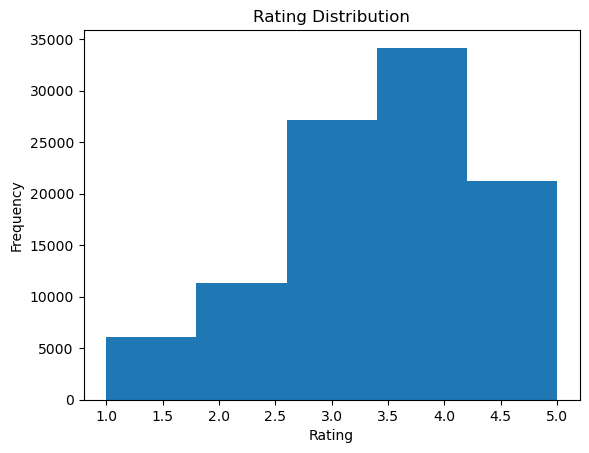

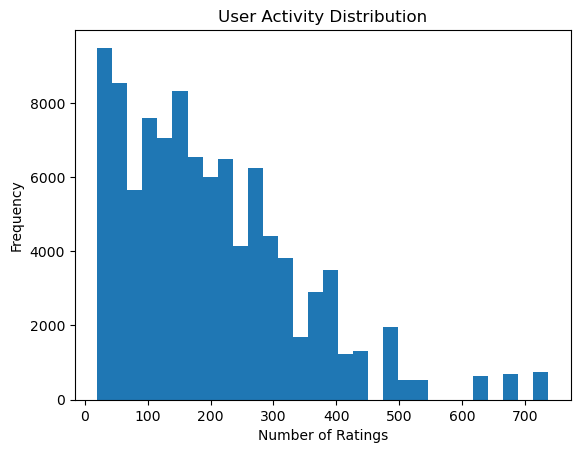

Linear Regression RMSE: 0.9289350193625742
Linear Regression R2: 0.31677583989728064
Random Forest RMSE: 1.00347623851492
Random Forest R2: 0.20272759792181083
Silhouette Score: 0.11473383924629227

Cluster Summary:
         user_avg_rating  rating_count   unknown    Action  Adventure  \
cluster                                                                 
0               3.683693    107.685552  0.000007  0.172158   0.090060   
1               3.547975    145.522857  0.000069  0.335945   0.197923   
2               3.506374     46.058333  0.000240  0.281575   0.090071   

         Animation  Children    Comedy     Crime  Documentary  ...   Fantasy  \
cluster                                                        ...             
0         0.022468  0.045064  0.296246  0.079604     0.011683  ...  0.007254   
1         0.054641  0.101684  0.313301  0.066776     0.003556  ...  0.018275   
2         0.009493  0.035024  0.197064  0.129497     0.004437  ...  0.004878   

         Film-Noi

In [1]:
# ===============================
# 1. Import libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score


# ===============================
# 2. Load dataset
# ===============================
# Replace this path with your own path if needed
path = 'C:/Users/liangbao/WPSDrive/ml-100k/'

ratings = pd.read_csv(path + 'u.data', sep='\t',
                      names=['user_id','movie_id','rating','timestamp'])

users = pd.read_csv(path + 'u.user', sep='|',
                    names=['user_id','age','gender','occupation','zip'])

movie_columns = [
    'movie_id','title','release_date','video_release_date','IMDb_URL',
    'unknown','Action','Adventure','Animation','Children','Comedy','Crime',
    'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical',
    'Mystery','Romance','Sci-Fi','Thriller','War','Western'
]

movies = pd.read_csv(path + 'u.item', sep='|',
                     encoding='latin-1', names=movie_columns)


# ===============================
# 3. Merge datasets
# ===============================
# Combine rating, user and movie information into one table
data = ratings.merge(users, on='user_id')
data = data.merge(movies, on='movie_id')


# ===============================
# 4. Feature engineering
# ===============================
# User average rating (captures user rating tendency)
data['user_avg_rating'] = data.groupby('user_id')['rating'].transform('mean')

# Number of ratings per user (user activity level)
data['rating_count'] = data.groupby('user_id')['rating'].transform('count')

# Movie average rating (movie popularity)
data['movie_avg_rating'] = data.groupby('movie_id')['rating'].transform('mean')


# ===============================
# 5. Exploratory Data Analysis (EDA)
# ===============================
# Distribution of ratings
plt.hist(data['rating'], bins=5)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# User activity distribution
plt.hist(data['rating_count'], bins=30)
plt.title('User Activity Distribution')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()


# ===============================
# 6. Regression Models (Rating Prediction)
# ===============================
# Select features and target variable
features = ['user_avg_rating','rating_count','movie_avg_rating']
X = data[features]
y = data['rating']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)


# ---- Random Forest ----
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)


# ===============================
# 7. Clustering (Audience Segmentation)
# ===============================
# Select genre columns
genre_cols = [
    'unknown','Action','Adventure','Animation','Children','Comedy','Crime',
    'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical',
    'Mystery','Romance','Sci-Fi','Thriller','War','Western'
]

# Compute user genre preference
user_genre_pref = data.groupby('user_id')[genre_cols].mean()

# Combine with user behavior features
user_features = data.groupby('user_id')[['user_avg_rating','rating_count']].mean()
user_features = user_features.merge(user_genre_pref, on='user_id')

# Standardize features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_features)

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

user_features['cluster'] = clusters

# Evaluate clustering
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)


# ===============================
# 8. Cluster interpretation
# ===============================
# Show average characteristics of each cluster
cluster_summary = user_features.groupby('cluster').mean()
print("\nCluster Summary:")
print(cluster_summary)